# EBM0D — Zero-Dimensional Energy Balance Model


In [201]:
import numpy as np
import matplotlib.pyplot as plt
import paleobeasts as pb
from paleobeasts.signal_models.ebm import EBM0D, OLR_func, albedo_func

{}


## Basic run

In [202]:
# Instantiate with all defaults: S0=1365, alpha=0.3, Stefan-Boltzmann OLR
model = EBM0D()

# Integrate from a cold start (255 K) to equilibrium
output = model.integrate(t_span=(0, 300), y0=[255.0], method='RK45')

{}


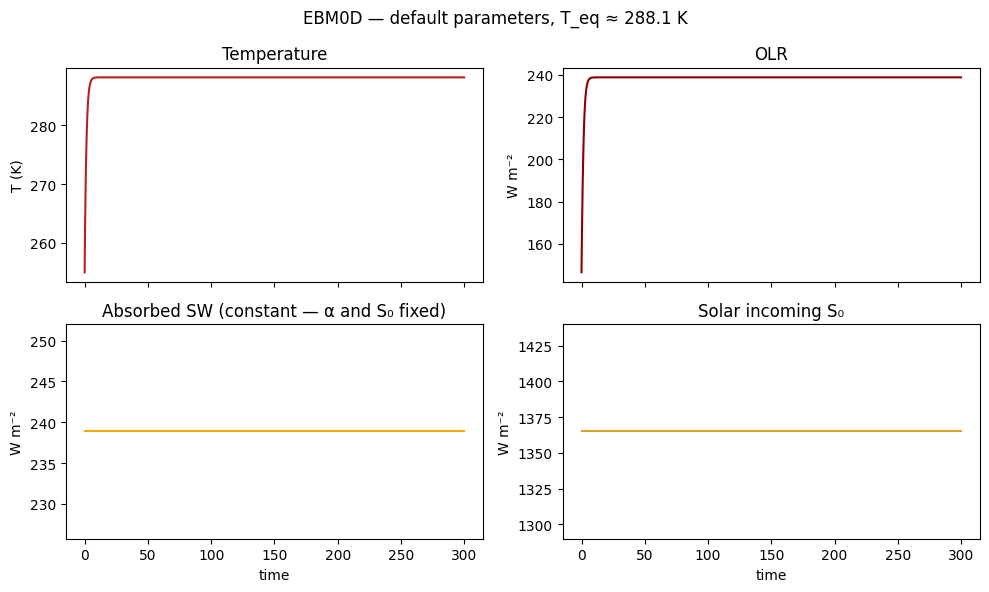

{}


In [203]:
# Unpack the arrays we will use throughout the notebook
time        = output.time
T           = output.state_variables['T']
albedo_diag = output.diagnostic_variables['albedo']
sw_diag     = output.diagnostic_variables['absorbed_SW']
olr_diag    = output.diagnostic_variables['OLR']
solar_diag  = output.diagnostic_variables['solar_incoming']

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

# Temperature rises from cold start to radiative equilibrium
axes[0, 0].plot(time, T, color='firebrick')
axes[0, 0].set_ylabel('T (K)'); axes[0, 0].set_title('Temperature')

# OLR tracks T — rises as the planet warms
axes[0, 1].plot(time, olr_diag, color='darkred')
axes[0, 1].set_ylabel('W m⁻²'); axes[0, 1].set_title('OLR')

# absorbed_SW is constant here: alpha=0.3 (fixed), S0=1365 (fixed)
# → absorbed = (1 − 0.3) × 1365 / 4 = 238.875 W m⁻² always
axes[1, 0].plot(time, sw_diag, color='orange')
axes[1, 0].set_ylabel('W m⁻²'); axes[1, 0].set_title('Absorbed SW (constant — α and S₀ fixed)')
axes[1, 0].set_xlabel('time')

# Solar incoming is likewise constant (no forcing attached)
axes[1, 1].plot(time, solar_diag, color='goldenrod')
axes[1, 1].set_ylabel('W m⁻²'); axes[1, 1].set_title('Solar incoming S₀')
axes[1, 1].set_xlabel('time')

fig.suptitle(f"EBM0D — default parameters, T_eq ≈ {T[-1]:.1f} K")
plt.tight_layout(); plt.show()

**Figure.** Starting from 255 K, the model equilibrates at ~288 K in ~100 yr. Top-left: temperature relaxes smoothly to the fixed point. Top-right: albedo starts low (warm reference) and converges to the equilibrium value (~0.3). Bottom-left: absorbed shortwave (constant once albedo stabilises). Bottom-right: OLR rises as the planet warms and balances the incoming solar at equilibrium.

## Albedo

`albedo` controls how much shortwave is reflected. It accepts three forms.

### 1. Constant float (default `0.3`)

Fixed reflectivity — a single radiative equilibrium exists.

### 2. `albedo_func` — built-in temperature-dependent feedback

`albedo_func` implements a quadratic ice-albedo transition:

- T < 260 K → α = 0.6 (ice-covered)
- T > 290 K → α = 0.3 (ice-free)
- Quadratic blend in between

The thresholds can be shifted with a lambda wrapper:
```python
albedo=lambda t, state: albedo_func(t, state, T1=255., T2=285.)
```

With `albedo_func` the model has **two stable equilibria**. Which one you land on depends entirely on the initial condition. Running from several starting temperatures makes this clear:

In [204]:
# --- setup: multiple initial conditions with albedo_func ---
initial_temps = [230, 245, 258, 268, 278, 288, 295]  # K

runs = []
for T0 in initial_temps:
    m = EBM0D(albedo=albedo_func)
    out = m.integrate(t_span=(0, 300), y0=[T0], method='RK45')
    runs.append((T0, out))

{}


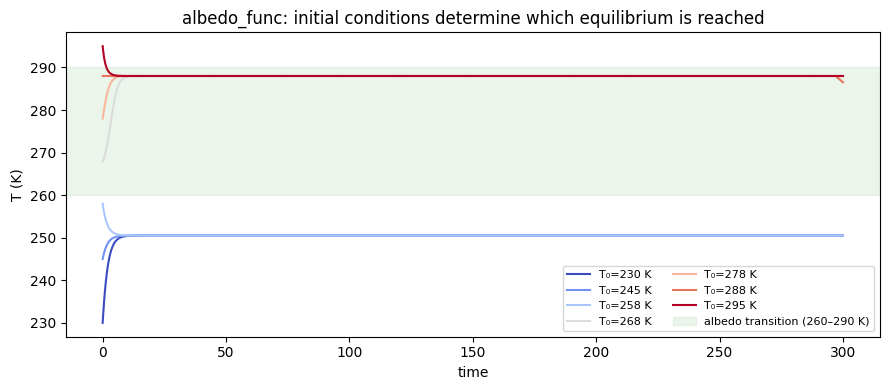

{}


In [205]:
# --- plot: each IC traces to one of two equilibria ---
fig, ax = plt.subplots(figsize=(9, 4))

colors = plt.cm.coolwarm(np.linspace(0, 1, len(initial_temps)))
for (T0, out), c in zip(runs, colors):
    t_run = out.time
    T_run = out.state_variables['T']
    ax.plot(t_run, T_run, color=c, label=f'T₀={T0} K')

# Mark the transition zone where albedo blends
ax.axhspan(260, 290, alpha=0.08, color='green', label='albedo transition (260–290 K)')
ax.set_xlabel('time'); ax.set_ylabel('T (K)')
ax.set_title('albedo_func: initial conditions determine which equilibrium is reached')
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

**Figure.** Multiple initial conditions reveal two stable equilibria separated by a tipping point. Cold starts (blue) are attracted to the snowball state (~230 K); warm starts (red) settle at the temperate state (~288 K). The shaded band (260–290 K) is the albedo transition zone — initial conditions within it can go either way depending on the exact value.

### 3. Custom callable

Any function with signature `(t)`, `(t, state)`, or `(t, state, model)` — first argument must be named `t` or `time`. The dispatcher inspects the signature automatically.

In [206]:
# --- setup: smooth tanh albedo transition ---
def tanh_albedo(t, state):
    """Smooth albedo: α ranges from 0.6 (cold) to 0.3 (warm),
    centred on 275 K with a 10 K width."""
    T = float(np.asarray(state).reshape(-1)[0])
    return 0.45 - 0.15 * np.tanh((T - 275.0) / 10.0)

# Show the functional form before integrating
T_range = np.linspace(240, 310, 200)
alb_tanh  = [tanh_albedo(0, [T]) for T in T_range]
alb_builtin = [albedo_func(0, [T]) for T in T_range]

{}


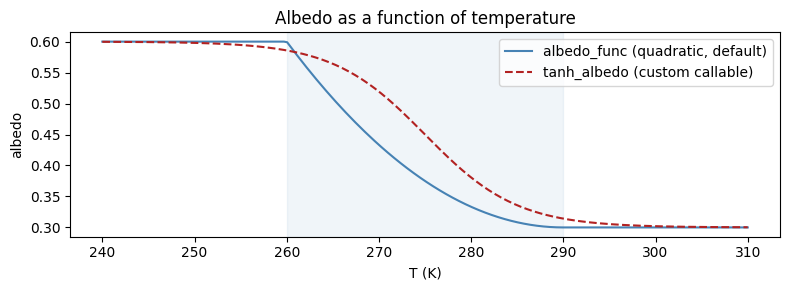

{}


In [207]:
# --- plot: compare albedo functions ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(T_range, alb_builtin, color='steelblue', label='albedo_func (quadratic, default)')
ax.plot(T_range, alb_tanh,   color='firebrick',  ls='--', label='tanh_albedo (custom callable)')
ax.axvspan(260, 290, alpha=0.08, color='steelblue')
ax.set_xlabel('T (K)'); ax.set_ylabel('albedo')
ax.set_title('Albedo as a function of temperature'); ax.legend(); plt.tight_layout(); plt.show()

**Figure.** Default (quadratic) vs custom (tanh) albedo as a function of temperature. Both switch from high-albedo (ice) to low-albedo (no ice) across a similar temperature range, but the tanh transition is sharper — a narrower bistable zone and a more abrupt tipping point.

In [208]:
# --- integrate with custom albedo ---
model_tanh = EBM0D(albedo=tanh_albedo)
out_tanh = model_tanh.integrate(t_span=(0, 300), y0=[255.0], method='RK45')
t_tanh = out_tanh.time
T_tanh = out_tanh.state_variables['T']
print(f"tanh_albedo equilibrium: T = {T_tanh[-1]:.1f} K")

tanh_albedo equilibrium: T = 250.9 K
{}


## OLR

The default OLR applies Stefan-Boltzmann at an effective emission level set by a dry-adiabatic pressure ratio. `OLR_func(pRad, ps)` returns the callable. Lower `pRad` means emission from higher, colder air → less OLR → warmer equilibrium.

In [209]:
# --- setup: compare two OLR parameterisations ---
model_olr600 = EBM0D(OLR=OLR_func(pRad=600))   # higher emission level
out_olr600 = model_olr600.integrate(t_span=(0, 300), y0=[255.0], method='RK45')
t6 = out_olr600.time
T6 = out_olr600.state_variables['T']

print(f"pRad=650 (default): T_eq = {T[-1]:.1f} K")
print(f"pRad=600:           T_eq = {T6[-1]:.1f} K")

pRad=650 (default): T_eq = 288.1 K
pRad=600:           T_eq = 294.8 K
{}


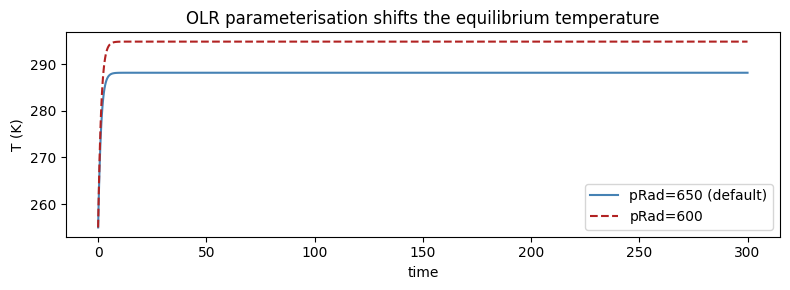

{}


In [210]:
# --- plot: equilibrium temperatures side by side ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time, T,  color='steelblue', label='pRad=650 (default)')
ax.plot(t6,   T6, color='firebrick', ls='--', label='pRad=600')
ax.set_xlabel('time'); ax.set_ylabel('T (K)')
ax.set_title('OLR parameterisation shifts the equilibrium temperature')
ax.legend(); plt.tight_layout(); plt.show()

**Figure.** A lower effective emission level (`pRad=600` hPa vs default 650 hPa) means radiation escapes from a colder, higher layer — the planet must warm further to achieve radiative balance. The equilibrium temperature shifts from ~288 K to ~292 K.

## Solar forcing: time-varying S₀

Forcings are attached after construction via `register_forcing('S0', forcing_obj)`. Because `S0` is a parameter, the default style is `'replacement'` — the forcing value replaces `S0` at each solver evaluation.

See the [Forcing notebook](../base_classes/forcing.ipynb) for a full treatment of all construction patterns (`Hold`, `Ramp`, `Harmonic`, array, callable, `from_csv`).

A quick example with a solar dimming–recovery sequence:

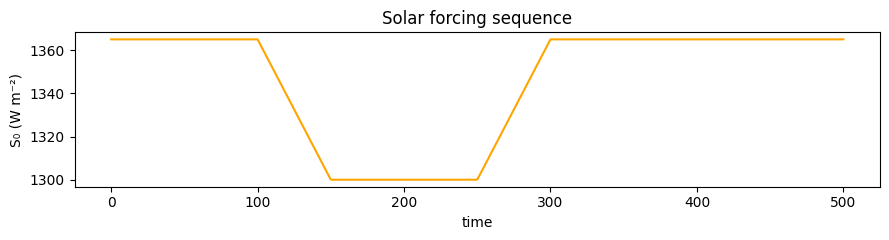

{}


In [211]:
# Build a solar dimming-recovery sequence
solar_seq = pb.core.Forcing.from_sequence([
    pb.core.Hold(duration=100, value=1365.0),
    pb.core.Ramp(duration=50,  y0=1365.0, yf=1300.0),
    pb.core.Hold(duration=100, value=1300.0),
    pb.core.Ramp(duration=50,  y0=1300.0, yf=1365.0),
    pb.core.Hold(duration=200, value=1365.0),
])

# Always plot the forcing before running
t_plot = np.linspace(0, 500, 1000)
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.plot(t_plot, [solar_seq.get_forcing(t) for t in t_plot], color='orange')
ax.set_xlabel('time'); ax.set_ylabel('S₀ (W m⁻²)')
ax.set_title('Solar forcing sequence'); plt.tight_layout(); plt.show()

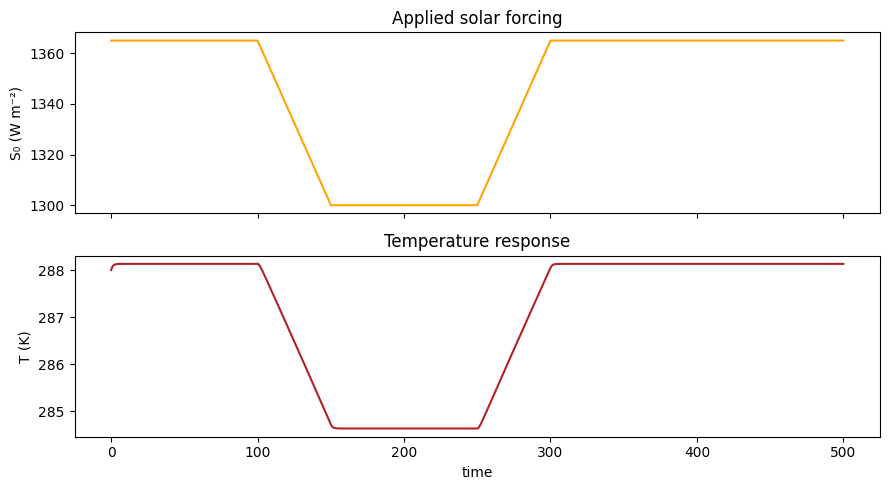

{}


In [212]:
# Attach to S0 and integrate
model_solar = EBM0D()
model_solar.register_forcing('S0', solar_seq)
out_solar = model_solar.integrate(t_span=(0, 500), y0=[288.0], method='RK45')

time_s  = out_solar.time
T_s     = out_solar.state_variables['T']
solar_s = out_solar.diagnostic_variables['solar_incoming']

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
# solar_incoming diagnostic confirms the forcing is applied correctly
axes[0].plot(time_s, solar_s, color='orange')
axes[0].set_ylabel('S₀ (W m⁻²)'); axes[0].set_title('Applied solar forcing')
axes[1].plot(time_s, T_s, color='firebrick')
axes[1].set_ylabel('T (K)'); axes[1].set_xlabel('time')
axes[1].set_title('Temperature response')
plt.tight_layout(); plt.show()

**Figure.** Top: `solar_incoming` diagnostic confirms the forcing is correctly applied — the ramp-down and ramp-up are clearly visible. Bottom: temperature tracks the forcing with a lag set by the heat capacity. The ~4 K cooling during the dimmed phase and subsequent recovery illustrate the model's sensitivity to solar variability.

### Bundled dataset: `from_csv`

`'vieira_tsi'` provides total solar irradiance reconstructed over the last millennium (time in years BP):

In [213]:
# --- load the Vieira TSI dataset ---
solar_vieira = pb.core.Forcing.from_csv(dataset='vieira_tsi')
print(f"Dataset span: {solar_vieira.time.min():.0f} – {solar_vieira.time.max():.0f} yr BP")
print(f"S0 range:     {solar_vieira.data.min():.2f} – {solar_vieira.data.max():.2f} W m⁻²")

Dataset span: 0 – 7840 yr BP
S0 range:     340.01 – 340.41 W m⁻²
{}


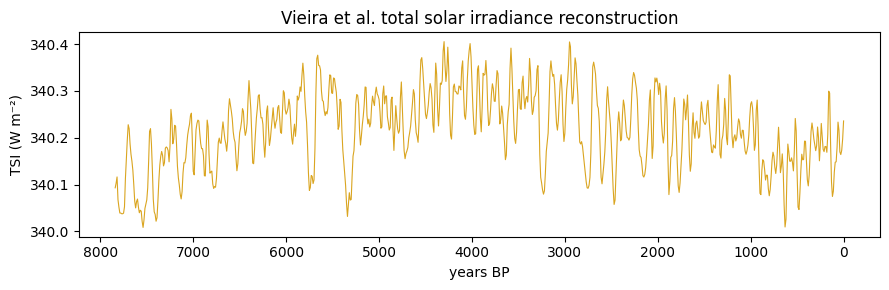

{}


In [214]:
# --- plot the dataset ---
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(solar_vieira.time, solar_vieira.data, color='goldenrod', lw=0.8)
ax.invert_xaxis()   # BP convention: older on the right
ax.set_xlabel('years BP'); ax.set_ylabel('TSI (W m⁻²)')
ax.set_title('Vieira et al. total solar irradiance reconstruction')
plt.tight_layout(); plt.show()

**Figure.** Vieira et al. total solar irradiance reconstruction over the Common Era (~850–2000 CE). Prominent features: the Medieval Grand Maximum (~1000 CE), the Maunder Minimum (~1650 CE), and the modern uptick. Variability is small (~1–2 W m⁻²) but sufficient to drive ~0.1–0.2 K global mean temperature fluctuations in the EBM0D.

## Time-evolving parameters

Any `param_values` entry can be a callable: `(t)`, `(t, state)`, or `(t, state, model)`.

`C` (heat capacity) controls the **speed** of equilibration — not the equilibrium temperature itself. The cleanest way to see this is to compare several constant C values all starting from the same initial condition. With Stefan-Boltzmann OLR the timescale is roughly τ ≈ C / (4 · OLR/T), so even modest differences in C produce clearly different approach curves.

In [215]:
# Integrate from a cold start (255 K) with four different constant heat capacities
C_values = [2, 8, 30, 100]   # W yr m⁻² K⁻¹
C_colors  = ["steelblue", "seagreen", "orange", "firebrick"]

C_runs = []
for C_val in C_values:
    m = EBM0D(C=C_val)
    out = m.integrate(t_span=(0, 500), y0=[255.0], method="RK45")
    C_runs.append((C_val, out))

# Confirm all reach the same equilibrium
for C_val, out in C_runs:
    print(f"C={C_val:>4}: T_eq = {out.state_variables['T'][-1]:.2f} K")

C=   2: T_eq = 288.13 K
C=   8: T_eq = 288.13 K
C=  30: T_eq = 288.13 K
C= 100: T_eq = 288.13 K
{}


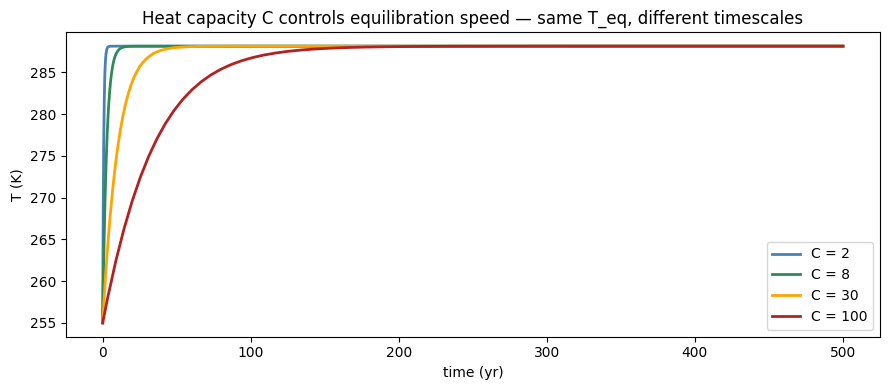

{}


In [216]:
fig, ax = plt.subplots(figsize=(9, 4))

for (C_val, out), color in zip(C_runs, C_colors):
    ax.plot(out.time, out.state_variables["T"],
            color=color, lw=2, label=f"C = {C_val}")

ax.set_xlabel("time (yr)")
ax.set_ylabel("T (K)")
ax.set_title("Heat capacity C controls equilibration speed — same T_eq, different timescales")
ax.legend(); plt.tight_layout(); plt.show()

**Figure.** All four runs converge to the same equilibrium temperature — heat capacity $C$ affects the equilibration timescale, not the fixed point. $C=2$ W yr m⁻² (thin atmosphere proxy) equilibrates in ~20 yr; $C=100$ (deep ocean mixed layer) takes ~500 yr. Choose $C$ to match the effective thermal inertia of the system being modelled.

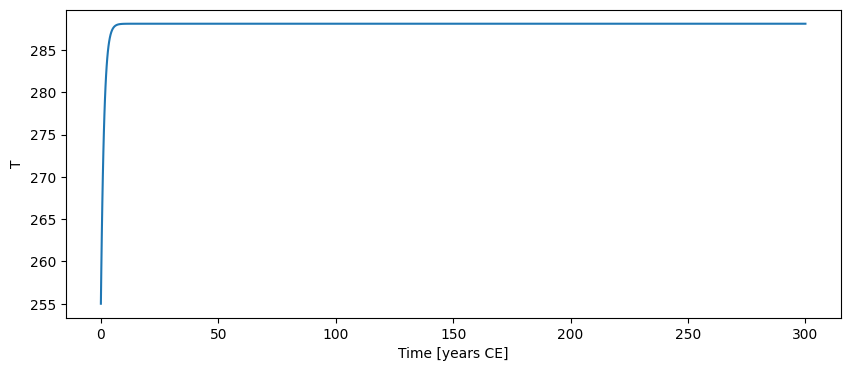

{}


In [217]:
# output.to_pyleo returns a pyleoclim Series (or MultipleSeries for multiple vars)
ts_T = output.to_pyleo(var_names=['T'])
ts_T.plot(); plt.show()

## Solver notes

**RK45** (adaptive, tight tolerances) is the correct choice for `EBM0D`. Fixed-step alternatives (`euler`, `rk4`) converge to the same equilibrium but are less efficient for smooth problems.

Worked comparisons — RK45 tolerances, Euler vs rk4, and bistability under different tolerances — are in the **`solver_demo`** notebook (`functionality_demos/solver_demo.ipynb`).